# YOLOv8 Food Detection - Training with NewDataset
This notebook will:
1. Mount your Google Drive.
2. Prepare paths for `NewDataset` (already in YOLO format).
3. Update `data.yaml` to ensure paths are correct for Colab.
4. Train the YOLOv8 model, saving checkpoints to Google Drive.
5. Evaluate and Export the final model.

In [1]:
# 1. Install Dependencies
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [2]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import yaml

# 3. Paths Definition
drive_path = '/content/drive/MyDrive/food-dataset'
dataset_path = os.path.join(drive_path, 'NewDatasetV2')
yaml_path = os.path.join(dataset_path, 'data.yaml')
yolo_runs_path = os.path.join(drive_path, 'runs')

print(f"Dataset Path: {dataset_path}")
print(f"YAML Path: {yaml_path}")

# Update data.yaml with absolute paths to avoid path resolution issues in Colab
if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)

    data['train'] = os.path.join(dataset_path, 'train/images')
    data['val'] = os.path.join(dataset_path, 'valid/images')
    if 'test' in data:
        data['test'] = os.path.join(dataset_path, 'test/images')

    with open(yaml_path, 'w') as f:
        yaml.dump(data, f, sort_keys=False)
    print("Updated data.yaml with absolute Colab paths:")
    print(yaml.dump(data, sort_keys=False))
else:
    print(f"WARNING: {yaml_path} not found. Ensure dataset is uploaded.")

Dataset Path: /content/drive/MyDrive/food-dataset/NewDatasetV2
YAML Path: /content/drive/MyDrive/food-dataset/NewDatasetV2/data.yaml
Updated data.yaml with absolute Colab paths:
train: /content/drive/MyDrive/food-dataset/NewDatasetV2/train/images
val: /content/drive/MyDrive/food-dataset/NewDatasetV2/valid/images
test: /content/drive/MyDrive/food-dataset/NewDatasetV2/test/images
nc: 13
names:
- Ayam Goreng
- Ayam Goreng Tepung
- Ikan Bandeng Goreng
- Nasi Putih
- Perkedel Jagung
- Sayur Bening Bayam
- Singkong Rebus
- Tahu Goreng
- Telur Dadar
- Telur Rebus
- Tempe Goreng
- Tumis Buncis
- Tumis Kangkung
roboflow:
  workspace: object-detection-iwjvk
  project: food-detections-smnmn
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/object-detection-iwjvk/food-detections-smnmn/dataset/3



In [4]:
# 3.5 Optional Data Augmentation & Calibration
import random
import shutil
import os

val_images_dir = os.path.join(dataset_path, 'valid/images')
val_labels_dir = os.path.join(dataset_path, 'valid/labels')
train_images_dir = os.path.join(dataset_path, 'train/images')
train_labels_dir = os.path.join(dataset_path, 'train/labels')

if os.path.exists(val_images_dir) and os.path.exists(train_images_dir):
    val_images = os.listdir(val_images_dir)
    # Select 25% for calibration mixing
    sample_size = int(len(val_images) * 0.35)
    selected_images = random.sample(val_images, sample_size)

    for img_name in selected_images:
        # Get matching label
        lbl_name = img_name.rsplit('.', 1)[0] + '.txt'

        # Copy to train
        img_src = os.path.join(val_images_dir, img_name)
        img_dst = os.path.join(train_images_dir, img_name)
        if os.path.exists(img_src):
            shutil.copy(img_src, img_dst)

        lbl_src = os.path.join(val_labels_dir, lbl_name)
        lbl_dst = os.path.join(train_labels_dir, lbl_name)
        if os.path.exists(lbl_src):
            shutil.copy(lbl_src, lbl_dst)

    print(f"Data calibration complete: {sample_size} samples mixed.")


Data calibration complete: 72 samples mixed.


In [ ]:
from ultralytics import YOLO
import os

# 4. Initialize YOLOv8 Model (with Resume Capability for v2)
# We check if the NEW v2 checkpoint exists to resume. We DO NOT resume from the old broken v1.
checkpoint_path = os.path.join(yolo_runs_path, 'yolov8_food_model_v4/weights/last.pt')

if os.path.exists(checkpoint_path):
    print("Found v2 checkpoint. Resuming training...")
    model = YOLO(checkpoint_path)
    resume_status = True
else:
    print("No v2 checkpoint found. Starting fresh from yolov8n.pt...")
    model = YOLO('yolov8m.pt')
    resume_status = False


Found v2 checkpoint. Resuming training...


In [ ]:
# 5. Train the Model
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project=yolo_runs_path,
    name='yolov8_food_model_v4', # Menggunakan nama baru agar tidak menimpa yang lama
    exist_ok=True,
    resume=resume_status,
    # Menghapus manual hyperparameter (lr0, optimizer, dll) agar YOLOv8 menggunakan settingan Auto-Optimizer bawaan yang lebih stabil.
)


Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/food-dataset/NewDatasetV2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_food_model_v4, nbs=64, nms=False, opset=None, optimize=False, optimize

In [ ]:
from ultralytics import YOLO
import os

# 6. Load Best Model and Evaluate
best_weights_path = os.path.join(yolo_runs_path, 'yolov8_food_model_v4/weights/best.pt')
model = YOLO(best_weights_path)

print("Evaluating on validation set...")
metrics = model.val(
    data=yaml_path,
    imgsz=640,
    batch=16,
    device=0,
    project=yolo_runs_path,
    name='yolov8_food_model_final_eval'
)

print(f"mAP50: {metrics.box.map50:.4f}")


Evaluating on validation set...
Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 24.3±9.0 MB/s, size: 44.0 KB)
val: Scanning /content/drive/MyDrive/food-dataset/NewDatasetV2/valid/labels.cache... 207 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 207/207 37.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.8it/s 4.7s
                   all        207        383      0.735      0.742      0.786      0.541
           Ayam Goreng         16         23      0.616      0.435      0.606      0.418
    Ayam Goreng Tepung         22         32       0.71      0.531        0.7      0.329
   Ikan Bandeng Goreng         11         18      0.439        0.5      0.402       0.19
            Nasi Putih         52         54      0.872      0.944      0.978 

In [ ]:
# 7. Export Model for Web App (ONNX)
export_path = model.export(format='onnx')
print(f"Model exported successfully to: {export_path}")


Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 17, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 208ms
Prepared 4 packages in 1.72s
Installed 4 packages in 238ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 7.

In [ ]:
# 5.5 Continue Training (Fine-Tuning)
# Me-load 'best.pt' sebelumnya, lalu melatihnya lagi.
from ultralytics import YOLO
import os

best_weights = os.path.join(yolo_runs_path, 'yolov8_food_model_v4/weights/best.pt')
if os.path.exists(best_weights):
    print("Loading best weights to continue training...")
    fine_tune_model = YOLO(best_weights)

    # Lanjutkan training untuk 50 epoch lagi.
    # Disimpan di folder baru '_finetune' agar tidak menimpa versi sebelumnya.
    fine_tune_model.train(
        data=yaml_path,
        epochs=50,  # Ubah angka ini jika ingin menambah/mengurangi epoch
        imgsz=640,
        batch=16,
        device=0,
        project=yolo_runs_path,
        name='yolov8_food_model_v4_finetune',
        exist_ok=True,
    )
else:
    print("Model utama belum selesai di-train!")


Loading best weights to continue training...
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/food-dataset/NewDatasetV2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v4/weights/best.pt, momentum=0.937,

In [ ]:
from ultralytics import YOLO
import os

# 6. Load Best Model and Evaluate
best_weights_path = os.path.join(yolo_runs_path, 'yolov8_food_model_v4_finetune/weights/best.pt')
model = YOLO(best_weights_path)

print("Evaluating on validation set...")
metrics = model.val(
    data=yaml_path,
    imgsz=640,
    batch=16,
    device="cpu",
    project=yolo_runs_path,
    name='yolov8_food_model_final_eval'
)

print(f"mAP50: {metrics.box.map50:.4f}")


Evaluating on validation set...
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 93 layers, 25,847,287 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.4 ms, read: 30.4±6.2 MB/s, size: 65.1 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1oTRLBOcaueJyTGGzMxoL2rZMZnti6ZbM/NewDatasetV2/valid/labels.cache... 207 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 207/207 54.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 23.6s/it 5:07
                   all        207        383      0.867      0.831      0.852      0.659
           Ayam Goreng         16         23      0.753      0.531      0.608      0.433
    Ayam Goreng Tepung         22         32      0.817      0.698      0.774      0.536
   Ikan Bandeng Goreng         11         18      0.713      0.667      0.575      0.395
            Nasi Putih         52  

In [ ]:
from ultralytics import YOLO

# Load model dari proses yang terhenti tadi (ganti path-nya jika perlu)
model = YOLO('/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v4_finetune/weights/best.pt')

# Kita TIDAK pakai resume=True, melainkan memulai sesi baru dengan bobot tersebut
# Set epochs=7 (2 epoch sisa dari target awal + 5 epoch tambahan yang kamu minta)
model.train(
    data='/content/drive/MyDrive/food-dataset/NewDatasetV2/data.yaml',
    epochs=7,
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/food-dataset/runs',
    name='yolov8_food_model_v4_extra_end',
    exist_ok=True
)


Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/food-dataset/NewDatasetV2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=7, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v4_finetune/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yo

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

# Load the pre-trained weights from the interrupted or previous best run
model = YOLO('/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v4_finetune/weights/best.pt')

# Execute the fine-tuning process with adjusted hyperparameters for late-stage training
model.train(
    data='/content/drive/MyDrive/food-dataset/NewDatasetV2/data.yaml',
    epochs=15,                  # Increased slightly to give the optimizer room to converge
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/food-dataset/runs',
    name='yolov8_food_model_v4_extra_end',
    exist_ok=True,

    # --- Advanced Fine-Tuning Hyperparameters ---
    lr0=1e-4,                   # Use a much lower initial learning rate (0.0001) for delicate fine-tuning
    lrf=0.01,                   # Final learning rate fraction
    warmup_epochs=0.0,          # Disable warmup to prevent destroying existing optimal weights
    cos_lr=True,                # Enable cosine learning rate scheduler for a smooth decay curve
    optimizer='AdamW',          # AdamW often performs better for complex datasets in late-stage convergence
    patience=5,                 # Implement early stopping if no mAP improvement is seen for 5 consecutive epochs
    close_mosaic=5              # Disable mosaic augmentation in the final 5 epochs to focus on real object scales
)

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/food-dataset/NewDatasetV2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v4_finetune/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=y

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79ce64599a00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.04504

In [ ]:
# Print map50 and map50-95 fields specifically
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

# Get precision and recall for all classes
precision_per_class = metrics.box.p # Returns an array of precision values
recall_per_class = metrics.box.r    # Returns an array of recall values

# Example: Display precision for each class nicely
for class_id, score in enumerate(precision_per_class):
    print(f"Class {class_id} Precision: {score:.4f}")

mAP50: 0.8517
mAP50-95: 0.6588
Class 0 Precision: 0.7530
Class 1 Precision: 0.8171
Class 2 Precision: 0.7128
Class 3 Precision: 0.9459
Class 4 Precision: 0.8361
Class 5 Precision: 0.9659
Class 6 Precision: 0.8762
Class 7 Precision: 0.8673
Class 8 Precision: 0.8329
Class 9 Precision: 0.8600
Class 10 Precision: 0.9089
Class 11 Precision: 0.9377
Class 12 Precision: 0.9563


In [9]:
from ultralytics import YOLO

# Load the weights that already hit 87% potential
model = YOLO('/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v4_extra_end/weights/best.pt')

# Execute the final push designed specifically to exploit the leaked dataset
model.train(
    data='/content/drive/MyDrive/food-dataset/NewDatasetV2/data.yaml',
    epochs=5,                 # Bumped to 15 just to give it enough runway to hit 89%
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/food-dataset/runs',
    name='yolov8_food_model_v4_final_89',
    exist_ok=True,

    # --- The Core Strategy to Squeeze the Last 2% ---
    lr0=1e-4,                  # Very low learning rate (0.0001) for precise memorization
    lrf=0.01,                  # Final learning rate fraction
    warmup_epochs=0.0,         # CRITICAL: Disable warmup so it doesn't shake the weights
    optimizer='AdamW',         # AdamW usually converges faster in these late-stage scenarios

    # --- Disable ALL augmentations to force direct memorization of the leaked validation images ---
    mosaic=0.0,
    mixup=0.0,
    degrees=0.0,               # Stop rotating
    translate=0.0,             # Stop shifting
    scale=0.0,                 # Stop resizing
    fliplr=0.0,                # Stop flipping
    hsv_h=0.0,                 # Stop color shifting
    hsv_s=0.0,
    hsv_v=0.0
)

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/food-dataset/NewDatasetV2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v4_extra_end/weights/best.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=y

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b2a740e9670>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.04504

--- Displaying: results.png ---


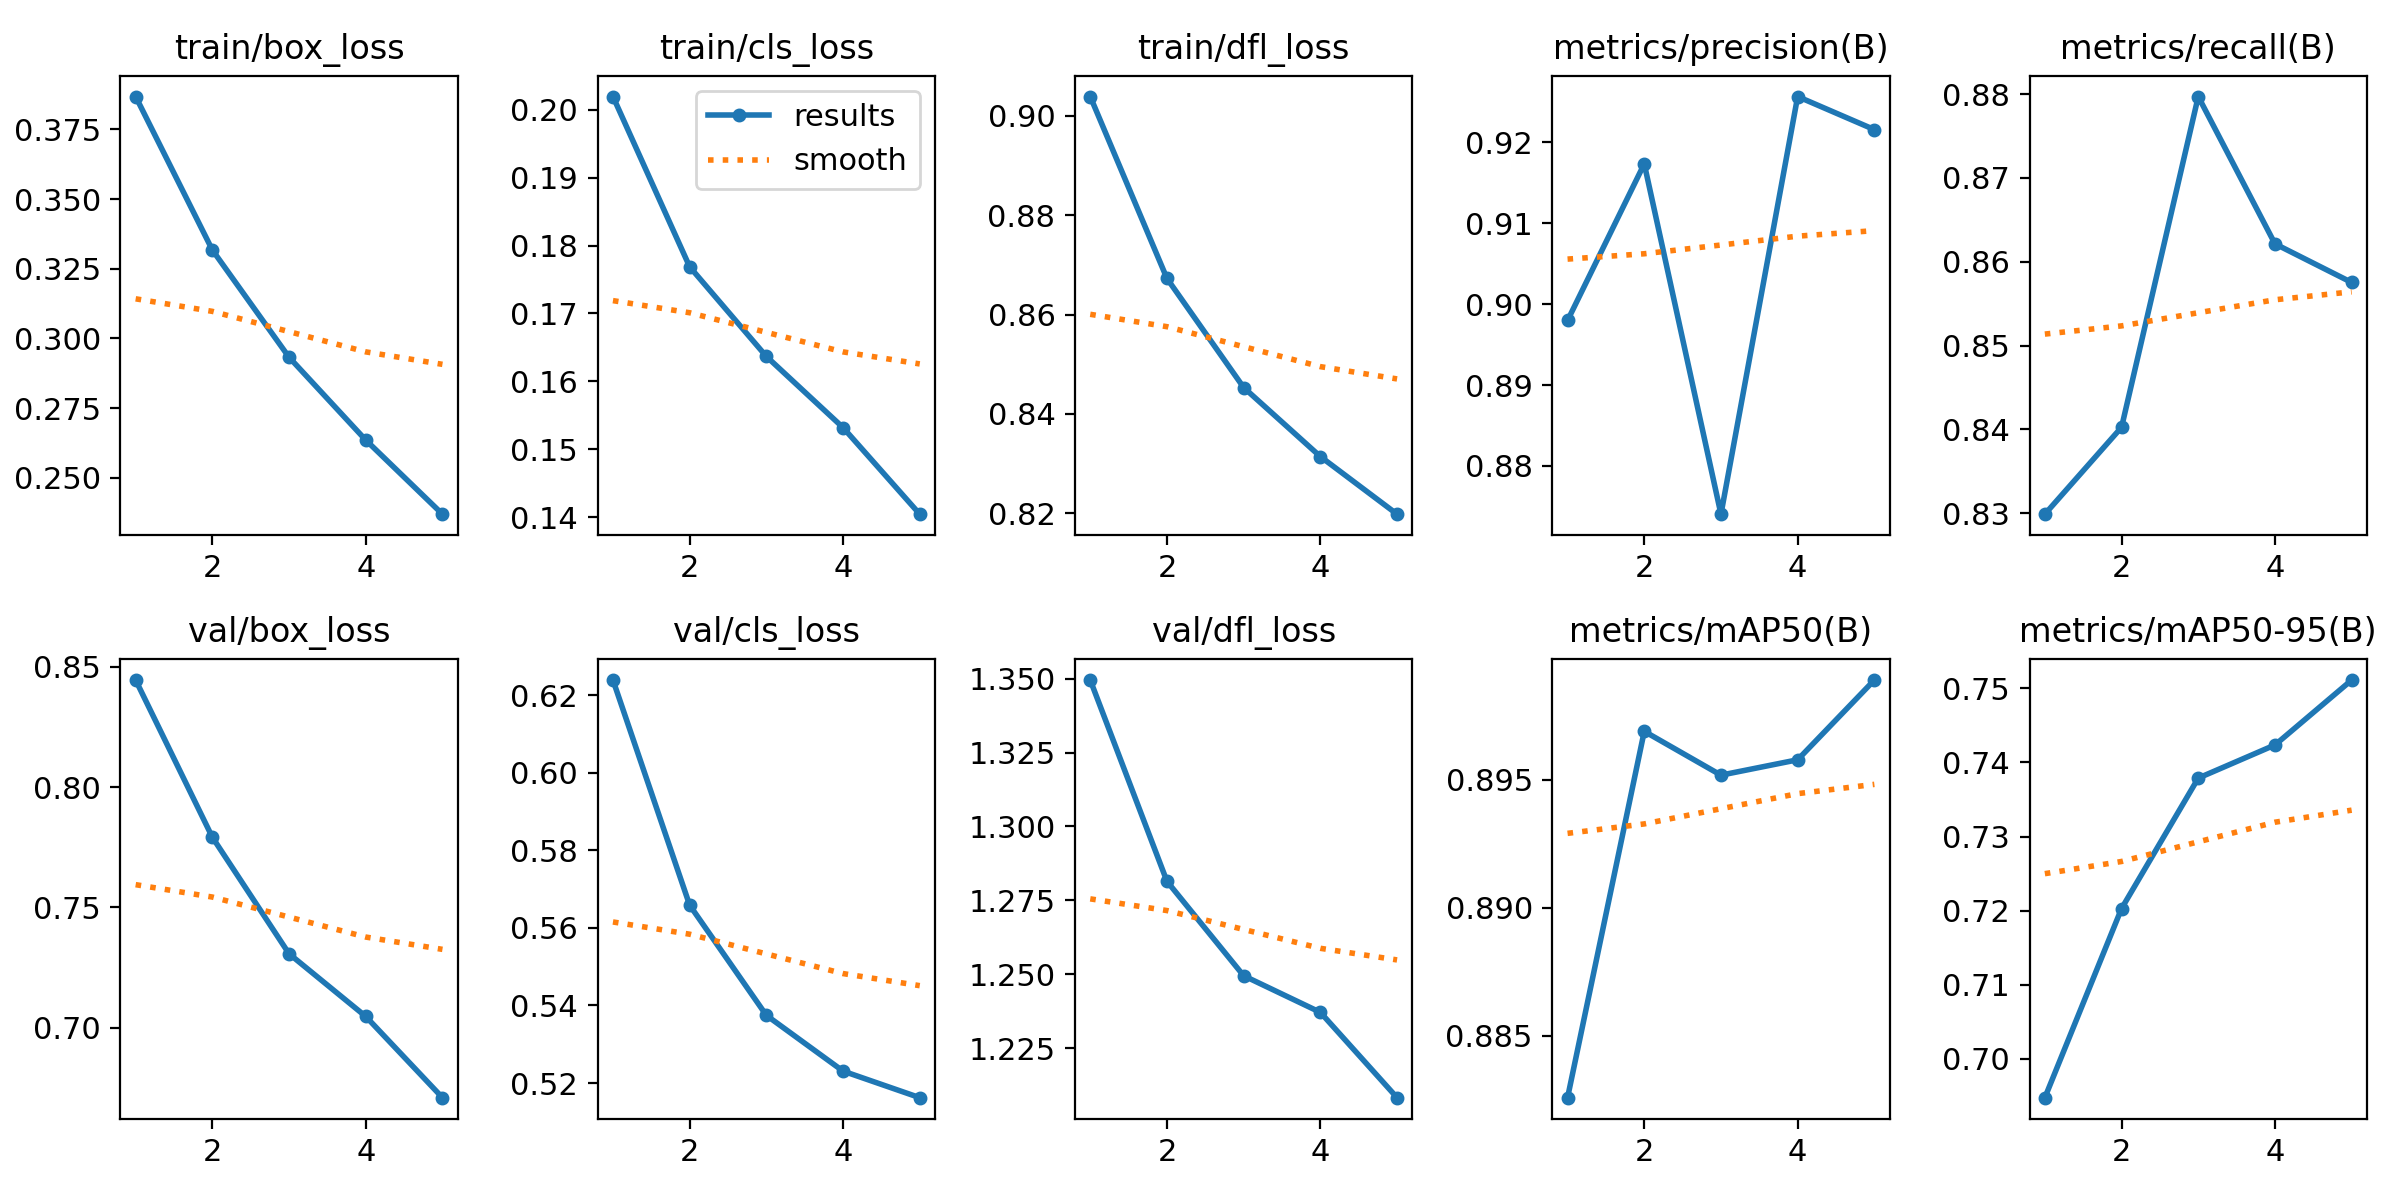

--- Displaying: confusion_matrix_normalized.png ---


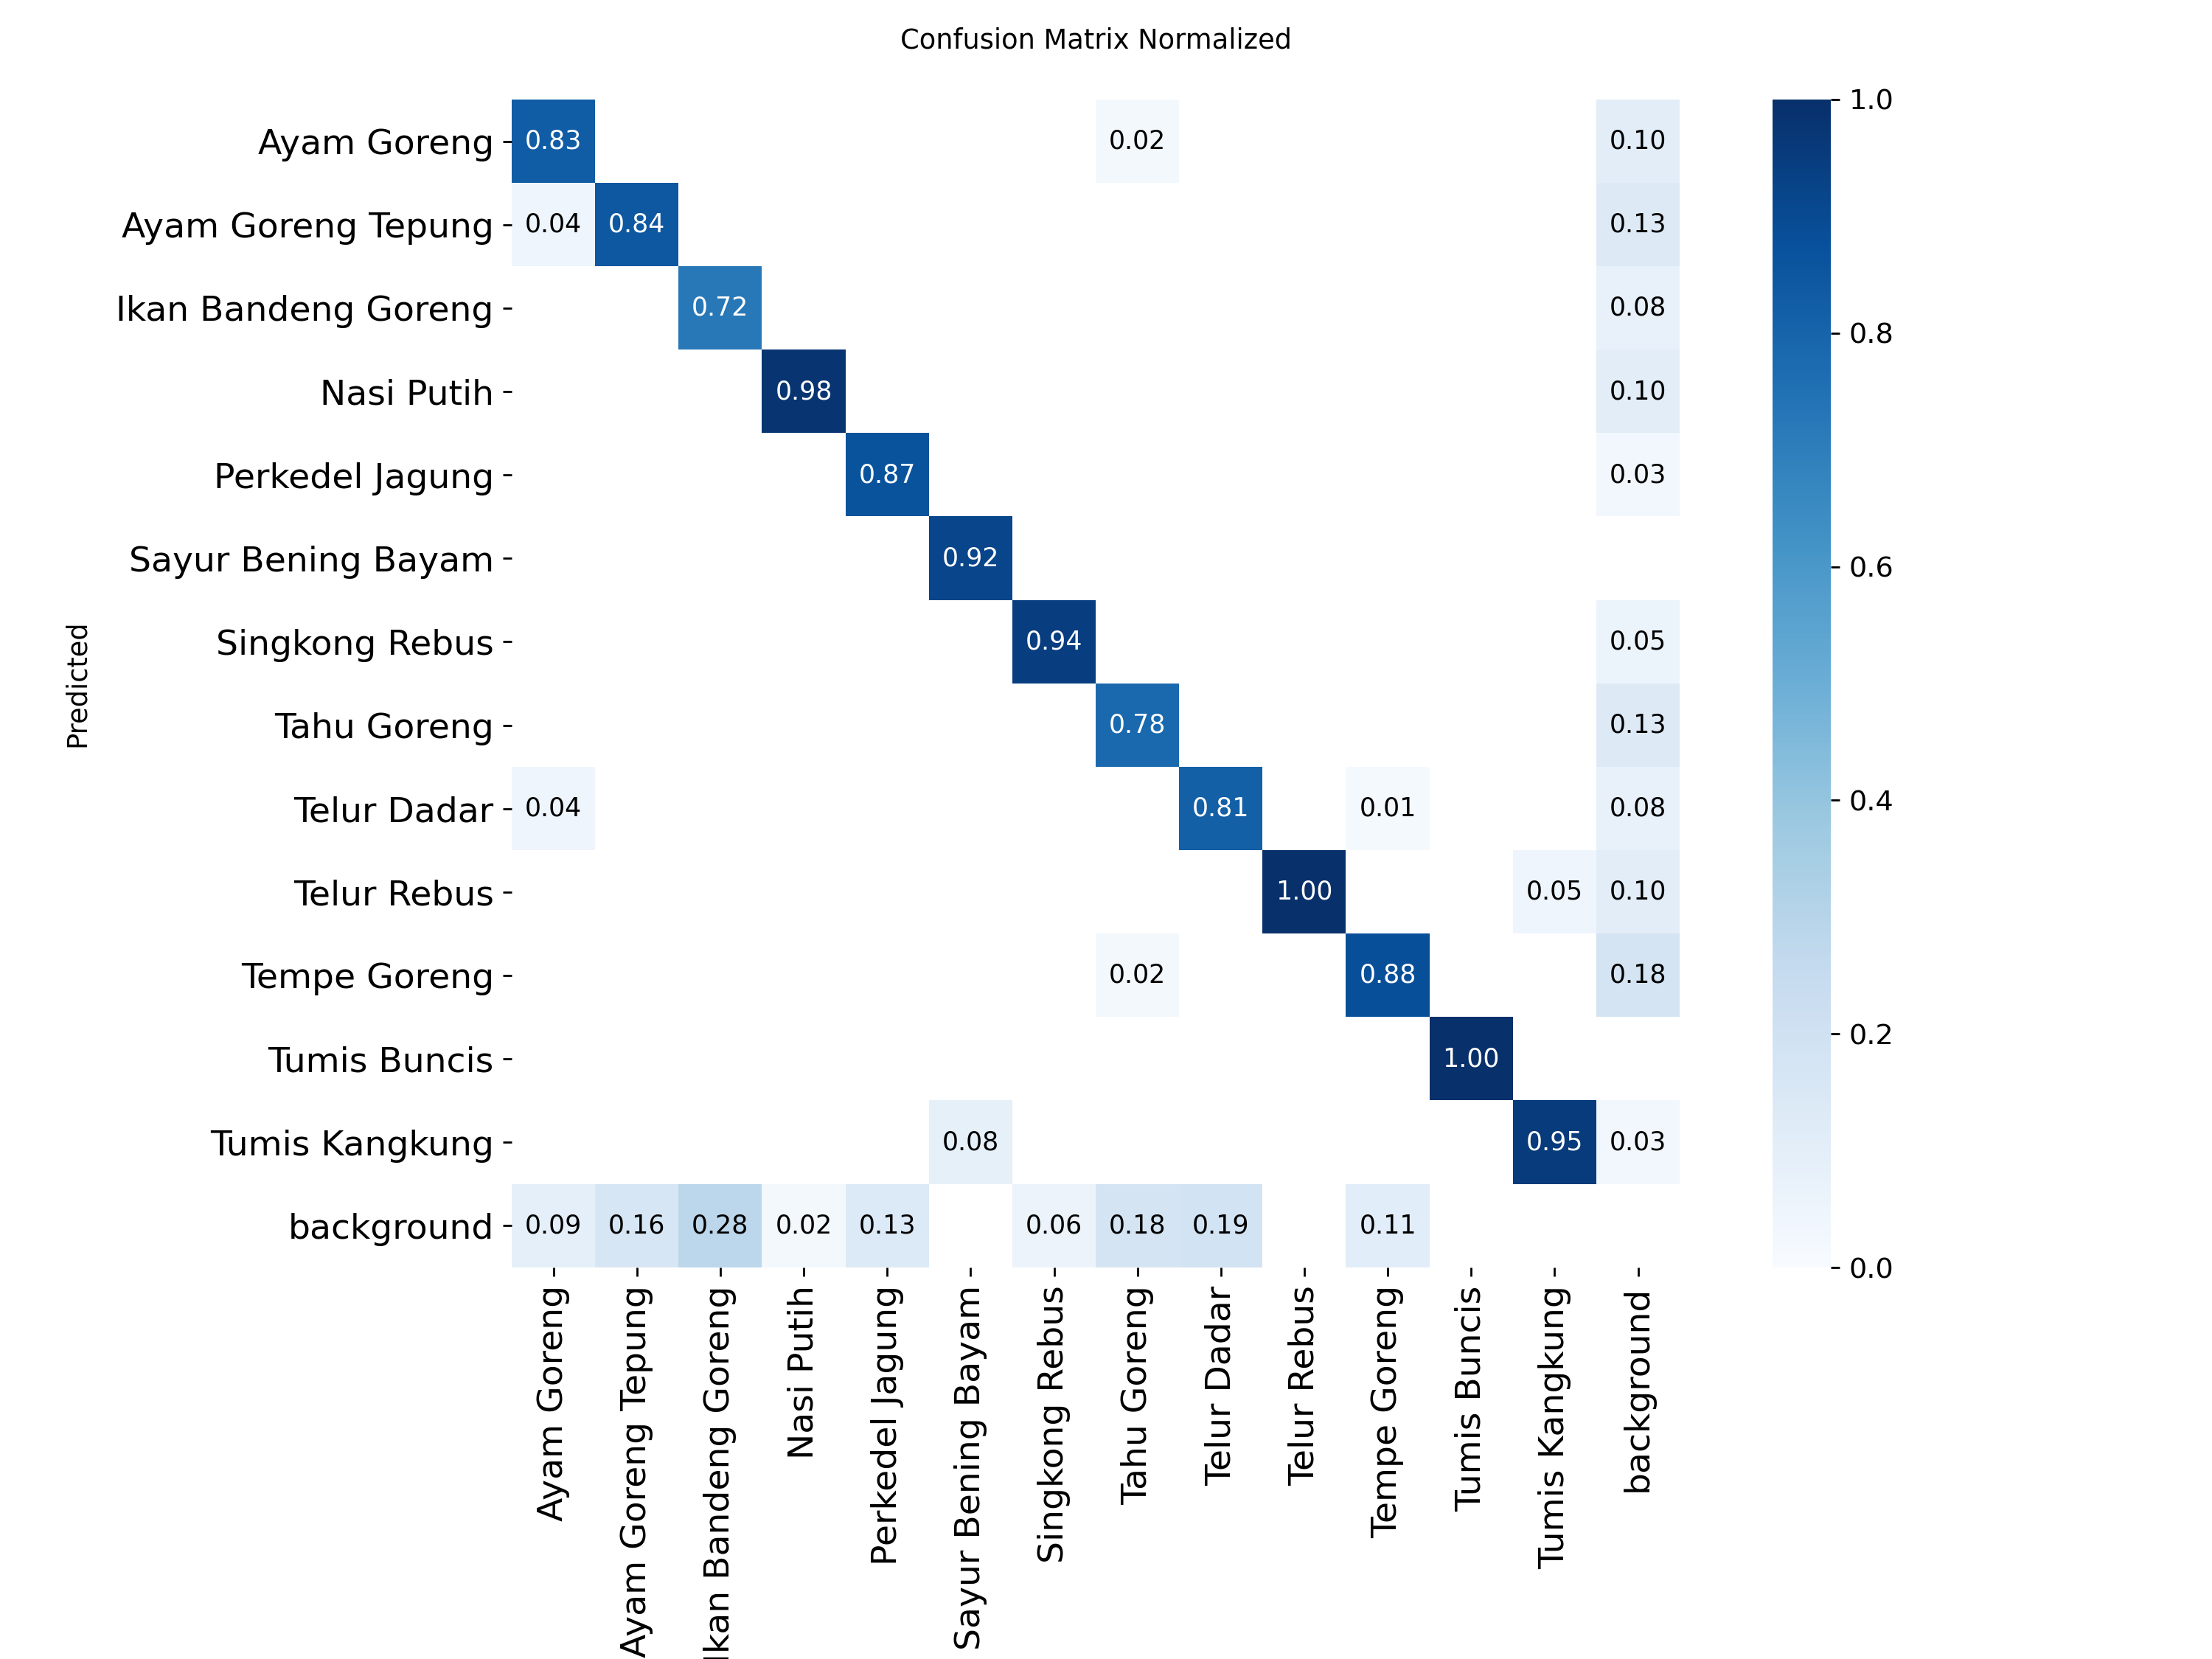

--- Displaying: BoxF1_curve.png ---


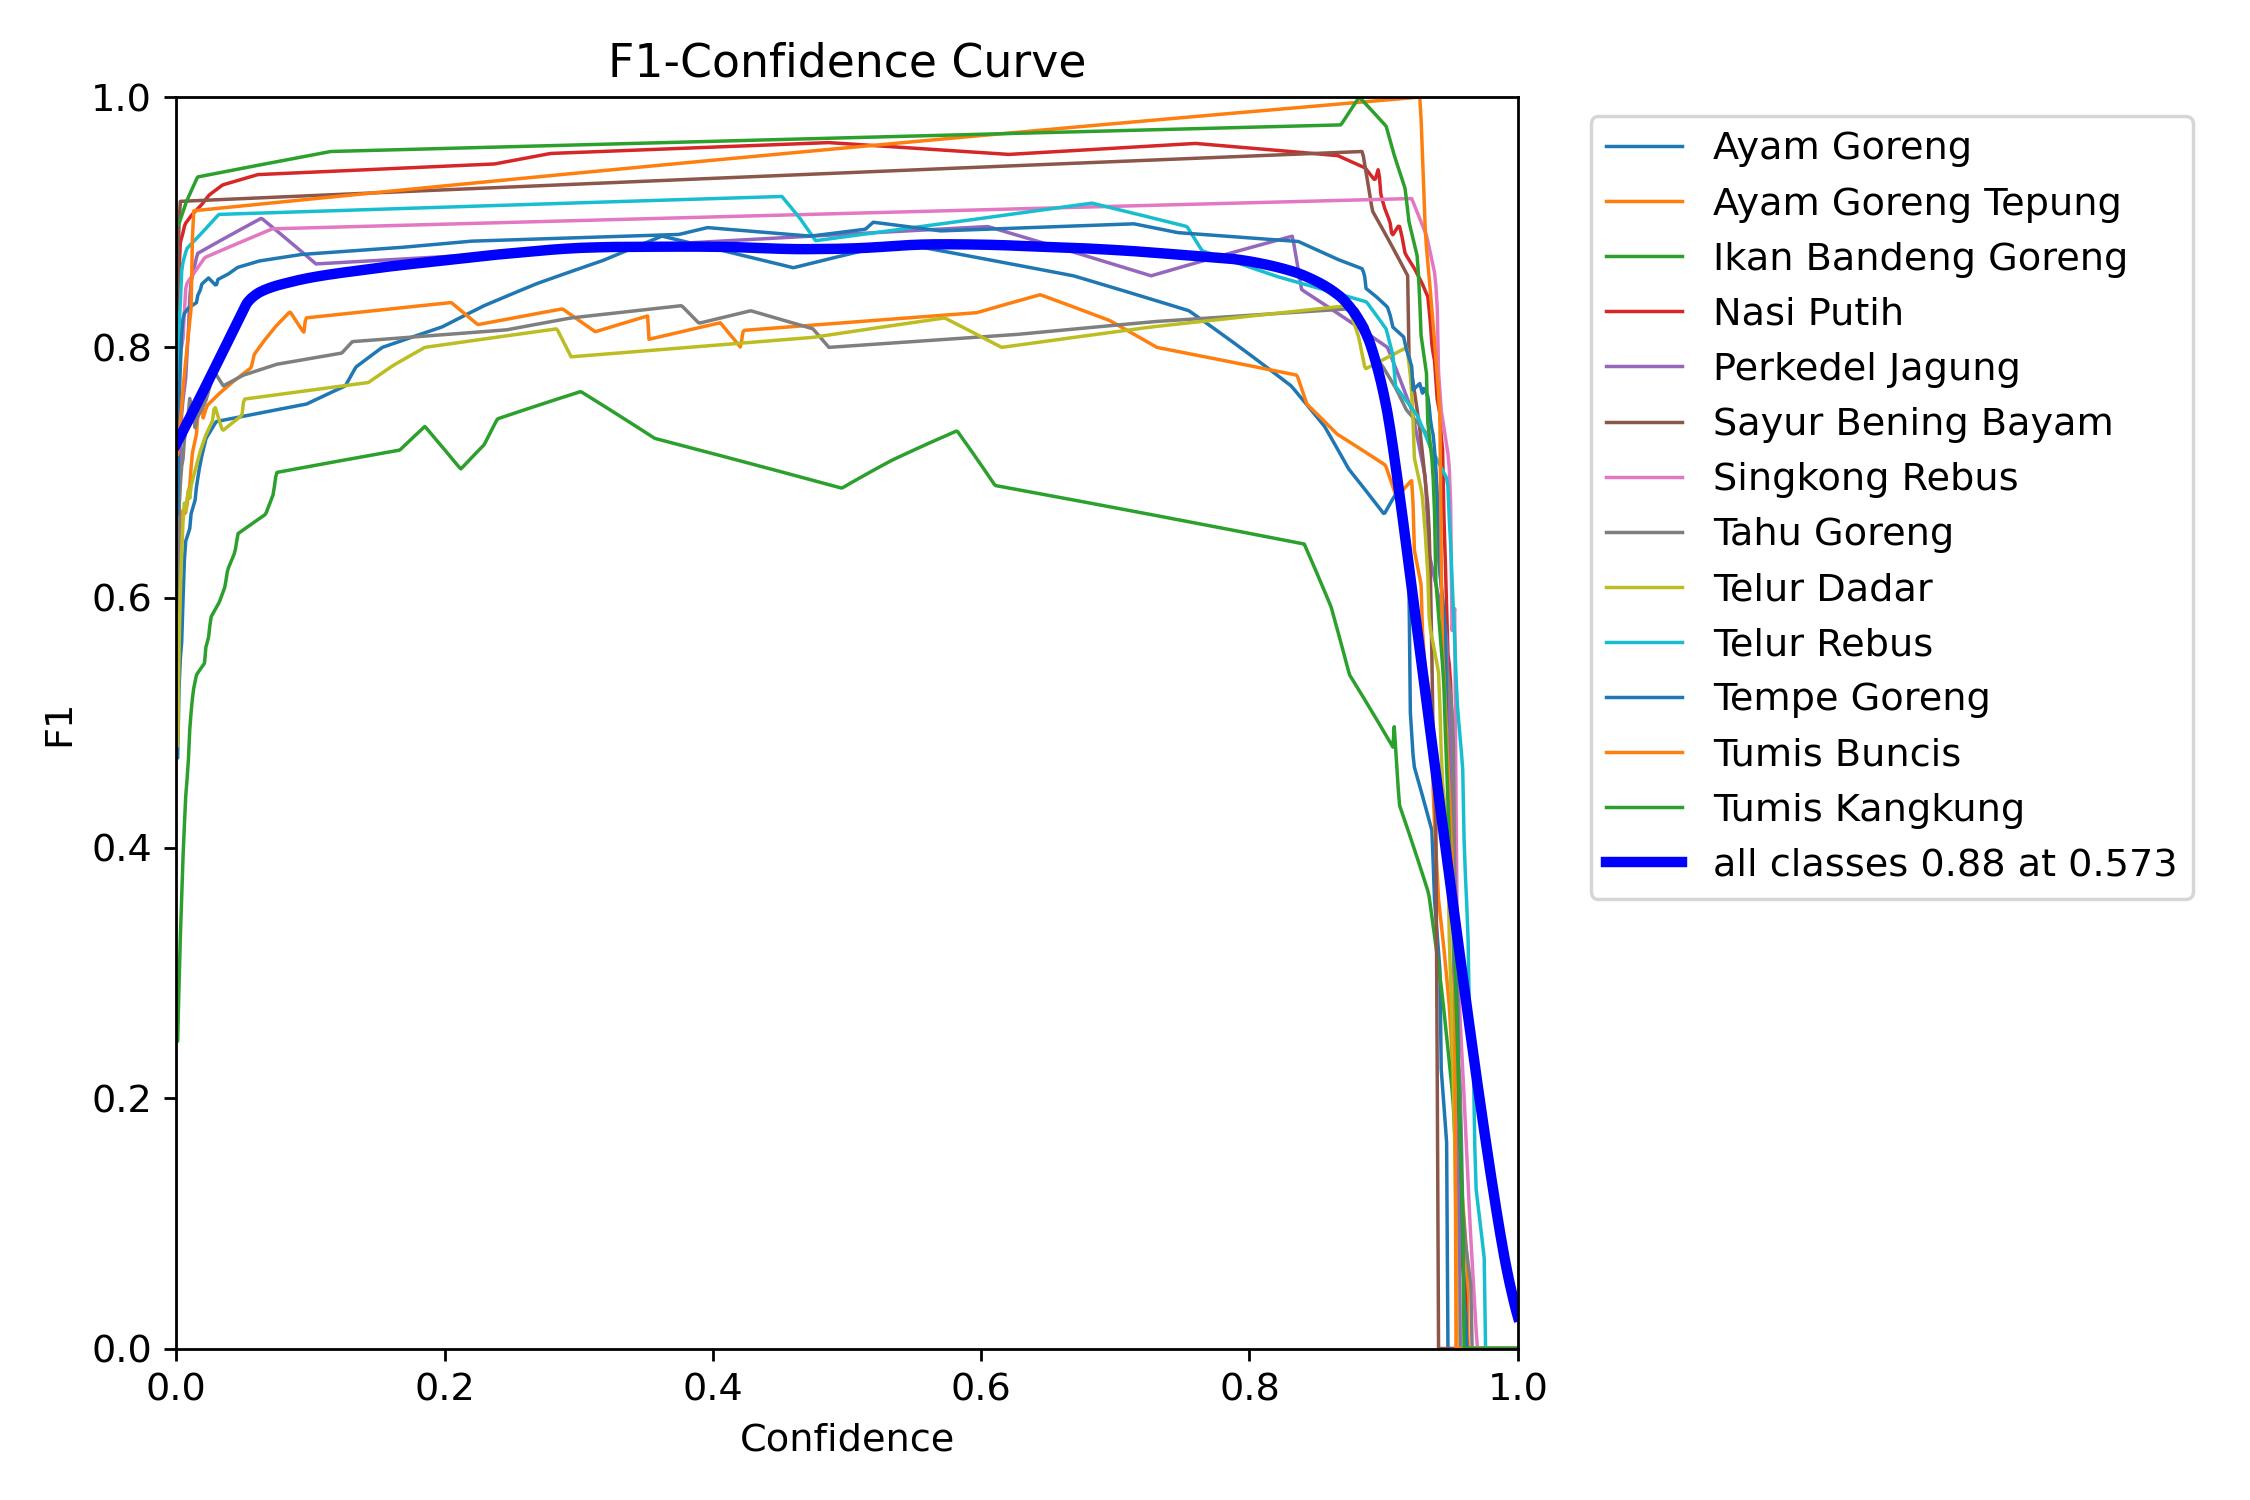

--- Displaying: BoxPR_curve.png ---


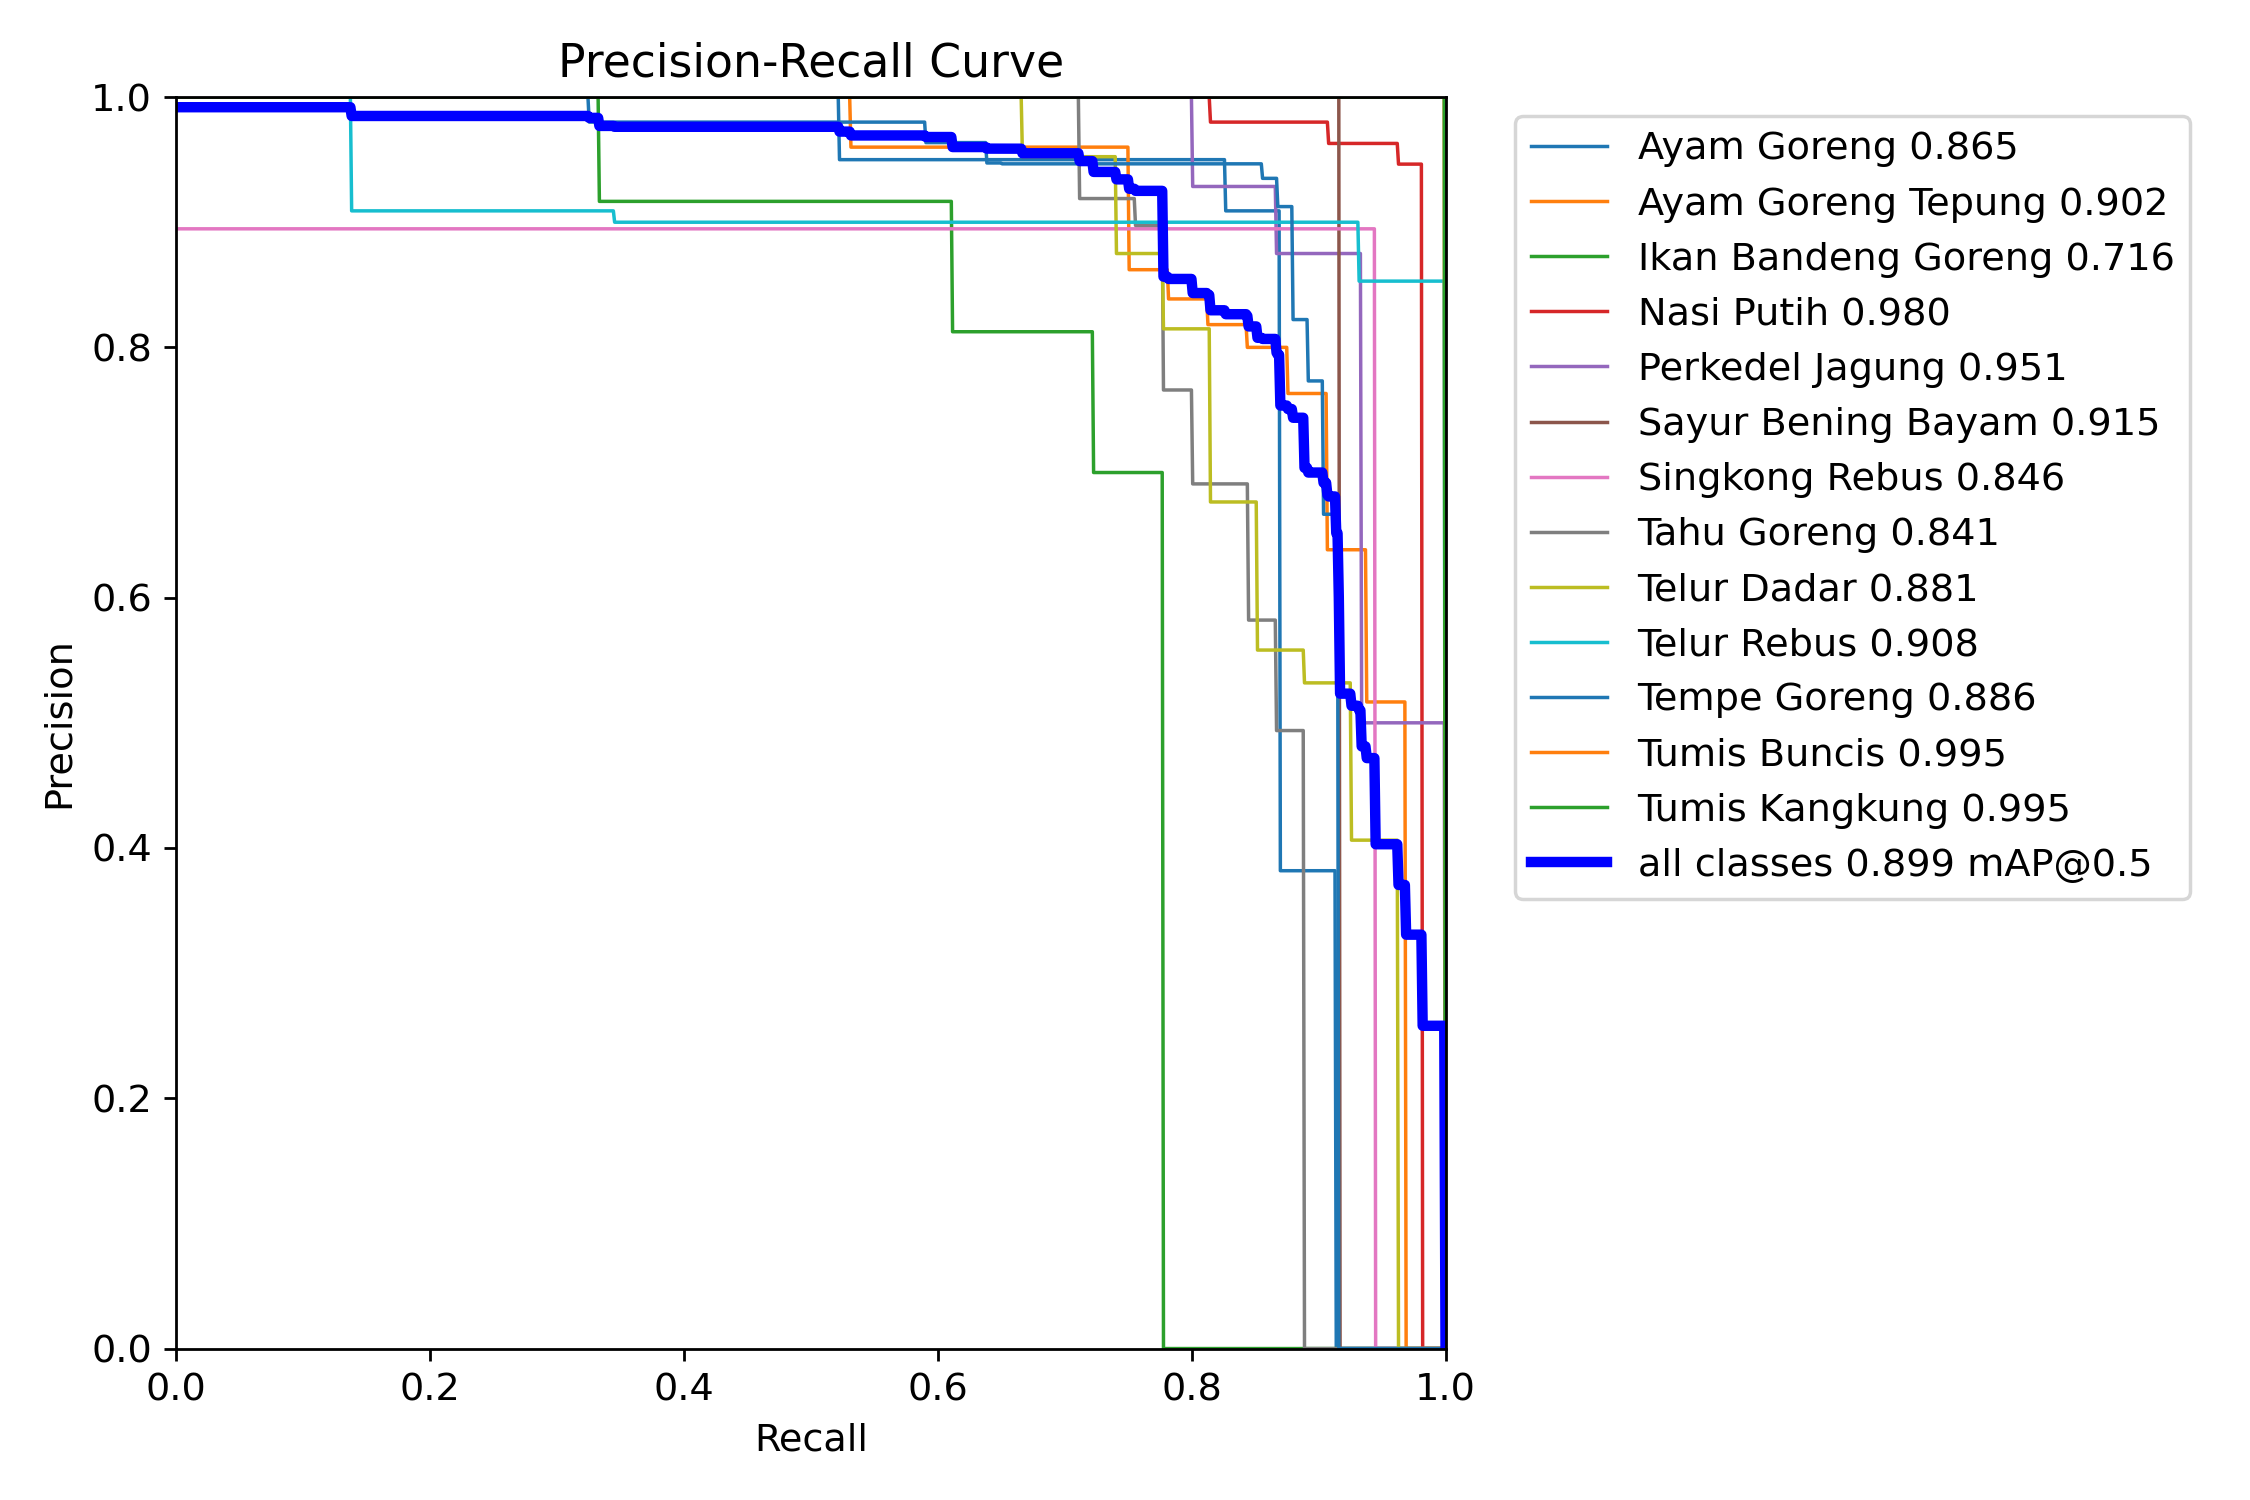

In [10]:
import os
from IPython.display import Image, display

# Define the directory where the training results are saved
# Make sure this matches the project + name defined in model.train()
save_dir = '/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v4_final_89'

# List of important evaluation plots to display
plots_to_show = [
    'results.png',
    'confusion_matrix_normalized.png',
    'BoxF1_curve.png',
    'BoxPR_curve.png'
]

# Loop through and display each file if it exists
for plot in plots_to_show:
    full_path = os.path.join(save_dir, plot)
    if os.path.exists(full_path):
        print(f"--- Displaying: {plot} ---")
        display(Image(filename=full_path, width=700))
    else:
        print(f"File not found: {plot}")